In [1]:
import skeliner as sk

In [2]:
mesh = sk.io.load_mesh("../dev/test_mesh_data_updated/BCs_hardcases/720575940552805191/mesh.obj")

In [3]:
# 1. Parallel patches
patches = sk.pre.find_parallel_patches(mesh, verbose=True)
if patches:
    mesh = sk.pre.remove_parallel_patches(mesh, patches=patches, verbose=True)

[skeliner.pre] Parallel patches: 6 patches, 33 faces
  Y=655368: 3f (+0 / -3)
  Y=663558: 16f (+2 / -14)
  Z=20517: 9f (+0 / -9)
  Z=20517: 1f (+1 / -0)
  Z=81963: 3f (+3 / -0)
  Z=81963: 1f (+0 / -1)
[skeliner.pre] Parallel patches: 1 Mode A (fold), 5 Mode B (parallel)
[skeliner.pre] Removing 33 patch faces
[skeliner.pre] No orphan components after removal


In [4]:
# 2. Organelles
orgs = sk.pre.find_organelles(mesh, verbose=True)

[skeliner.pre] Auto radius: 535.4 (5.0x median edge 107.1)
[skeliner.pre] Components: 30 total, 1 structural (>= 100 faces)
[skeliner.pre] Raw internal faces: 60,402 (35.3%)
[skeliner.pre] Isolated: 11 via outward_dots, 18 via geometric fallback
[skeliner.pre] Isolated fragments: 25 (428 faces), 4 external (kept)
[skeliner.pre] Structural components: main + 1 disconnected (38f)
[skeliner.pre] Rims: 22 pockets (fold >= 3.0), 16,126 mouth edges
[skeliner.pre] Pockets: 22, pocket mouth edges: 16,126, seeds: 13,602
[skeliner.pre] Pocket organelles (>= 5): 63,298 faces (initial 52,556, bridged +0, holes +10,937, rejected 4)
[skeliner.pre] Pocket organelles: 63,298 faces (main: 63,298, other: 0)
[skeliner.pre] find_organelles done: pocket=63,298, isolated=428 (12.5s)


[find_nucleus_center] 85,697 vertices, ~343 Z-levels
[find_nucleus_center] nucleus: center=(352109, 660414, 81984), Z=[81774,82194], peak_r=1077 nm, 3 Z-levels
[skeliner.pre] Soma (ring): nucleus center=(352109, 660414, 81984)
[skeliner.pre] Soma (ring): building vertex adjacency...
[skeliner.pre] Soma (ring): BFS ring analysis...
[skeliner.pre] Soma (ring): seed ring 0: 4374 verts (soma surface at mid-Z)
[skeliner.pre] Soma (ring): peak ring 1, cutoff ring 19/603 (peak search limit 12)
[skeliner.pre]   soma verts: 17,120 inside ellipsoid
[skeliner.pre]   soma verts: +2,627 dilated → 19,747
[skeliner.pre]   soma verts: +115 absorbed pockets → 19,862
[skeliner.pre]   soma verts: 268 verts in 1 neurite branches preserved
[skeliner.pre]   soma verts: +77 disconnected → 19,939
[skeliner.pre] Soma (ring): excluded 5,964 organelle verts → 13,975
[skeliner.pre] Soma (ring): center=[351454, 659450, 81648], axes=[3177, 2540, 1461], 13,975 surface verts (cutoff ring 19)


(<Figure size 800x800 with 4 Axes>,
 [<Axes: title={'center': 'XY'}, xlabel='x', ylabel='y'>,
  <Axes: title={'center': 'XZ'}, xlabel='x', ylabel='z'>,
  <Axes: title={'center': 'ZY'}, xlabel='z', ylabel='y'>])

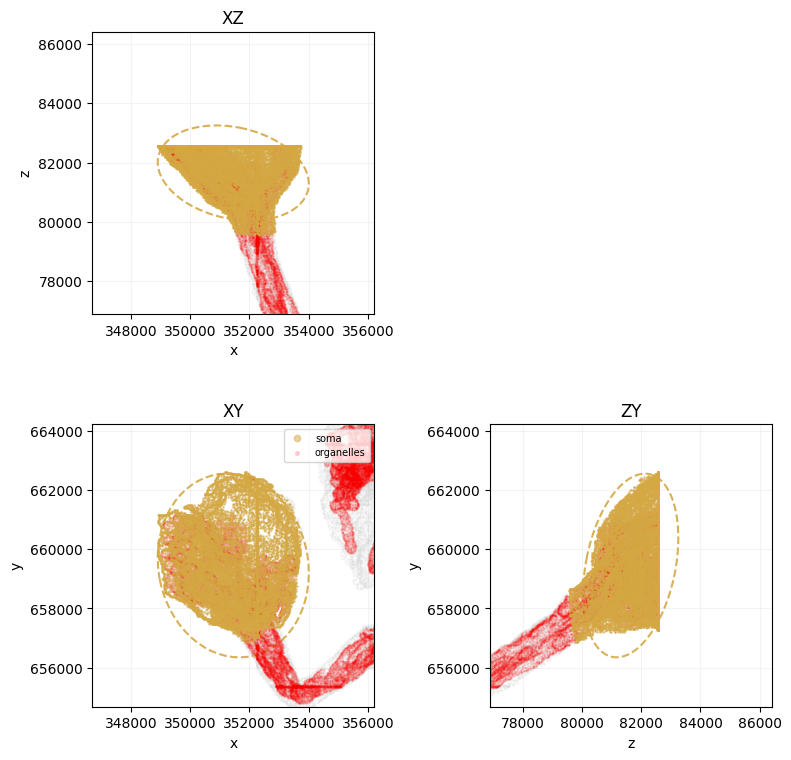

In [5]:
# 3. Soma
soma = sk.pre.find_soma_via_ring_cutoff(mesh, organelles=orgs.mask, mesh_stats=orgs.mesh_stats, verbose=True)
sk.plot.vis2d.soma_diagnostics(mesh=mesh, soma=soma, organelles=orgs.mask, figsize=(8,8))

In [6]:
# 4. Disconnected → gaps
disconnected = sk.pre.find_disconnected(mesh, soma=soma, organelles=orgs.mask, mesh_stats=orgs.mesh_stats, verbose=True)

gaps = sk.pre.find_gaps(mesh, soma=soma, disconnected=disconnected, mesh_stats=orgs.mesh_stats, verbose=True)
if gaps:
    mesh = sk.pre.remove_gaps(mesh, gaps=gaps, verbose=True)

[skeliner.pre] Disconnected: 30 total components
[skeliner.pre] Disconnected: building KDTree...
[skeliner.pre] Disconnected: 29 non-main components, 19 dropped by < 7 filter
[skeliner.pre] Disconnected: 0 components, 0 faces, 10 organelle excluded
[skeliner.pre] Gaps: 0 disconnected components


In [7]:
# 5. Fusions
fusions = sk.pre.find_fusions(mesh, mesh_stats=orgs.mesh_stats, verbose=True)
if fusions:
    mesh = sk.pre.remove_fusions(mesh, fusion_clusters=fusions, verbose=True)

[skeliner.pre] Mesh: 171,342 faces, 116 zero-area, 6 non-manifold edges
[skeliner.pre] Scanning 85,697 vertices for fan fusions ...
[skeliner.pre]   Fan vertex 912: 2 components, sizes [3, 2]
[skeliner.pre]   Fan vertex 5968: 2 components, sizes [5, 4]
[skeliner.pre]   Fan vertex 22417: 2 components, sizes [2, 1]
[skeliner.pre]   Fan vertex 54989: 2 components, sizes [10, 2]
[skeliner.pre]   Fan vertex 64976: 2 components, sizes [6, 3]
[skeliner.pre] Fusions: scanned 85,697 vertices, 5 fan fusions found
[skeliner.pre] Fusion seeds: 3 clusters, 15 faces (nm_neg=13, dupes=4, fan_verts=5)
[skeliner.pre] Growing seed cluster 1/3 (5f) ...
[skeliner.pre]   ring 3: 43f, 3 comps (2 >= 5f)
[skeliner.pre]   Seed cluster (5f): split at ring 3, region 43f, branches 24+17f, boundary 0f
[skeliner.pre] Growing seed cluster 2/3 (3f) ...
[skeliner.pre]   ring 3: 32f, 1 comps (1 >= 5f)
[skeliner.pre]   ring 4: 48f, 1 comps (1 >= 5f)
[skeliner.pre]   ring 5: 71f, 1 comps (1 >= 5f)
[skeliner.pre]   ring 6

In [8]:
# 6. Break up mesh
if soma is not None:
    components = sk.pre.break_up_mesh(mesh, soma, orgs, verbose=True)

break_up_mesh: absorbed 160 faces (137 verts) as missed soma
break_up_mesh: absorbed 4 faces (6 verts) as missed soma
break_up_mesh: absorbed 4 faces (6 verts) as missed soma
break_up_mesh: absorbed 3 faces (5 verts) as missed soma
break_up_mesh: absorbed 2 faces (4 verts) as missed soma
break_up_mesh: absorbed 1 faces as missed organelle (trapped)
break_up_mesh: 1 neurites, 8 discarded (1,225 faces, threshold ~82119 faces), soma 14,109 verts, organelle 63,727 faces


In [9]:
# 7. Compact
mesh, components = sk.pre.compact_mesh(mesh, components=components, verbose=True)

[skeliner.pre] Compact: 85,698 → 85,694 verts (4 removed), 171,342 → 171,271 faces (71 removed)
[skeliner.pre] Soma remap: 14,109 → 14,107 verts (2 dropped)


In [10]:
# Or run the entire pipeline in one call:
result = sk.pre.preprocess(mesh, verbose=True)
mesh, components = result.mesh, result.components

[skeliner.pre] Parallel patches: 0 patches, 0 faces
[skeliner.pre] Auto radius: 535.4 (5.0x median edge 107.1)
[skeliner.pre] Components: 30 total, 1 structural (>= 100 faces)
[skeliner.pre] Raw internal faces: 60,386 (35.3%)
[skeliner.pre] Isolated: 11 via outward_dots, 18 via geometric fallback
[skeliner.pre] Isolated fragments: 25 (428 faces), 4 external (kept)
[skeliner.pre] Structural components: main + 1 disconnected (5f)
[skeliner.pre] Rims: 22 pockets (fold >= 3.0), 16,125 mouth edges
[skeliner.pre] Pockets: 22, pocket mouth edges: 16,125, seeds: 13,602
[skeliner.pre] Pocket organelles (>= 5): 63,290 faces (initial 52,547, bridged +0, holes +10,938, rejected 4)
[skeliner.pre] Pocket organelles: 63,290 faces (main: 63,290, other: 0)
[skeliner.pre] find_organelles done: pocket=63,290, isolated=428 (12.4s)
[find_nucleus_center] 85,694 vertices, ~343 Z-levels
[find_nucleus_center] nucleus: center=(352109, 660414, 81984), Z=[81774,82194], peak_r=1077 nm, 3 Z-levels
[skeliner.pre] So

In [11]:
# save mesh and components
sk.io.save_mesh(mesh=mesh, path="./mesh_cleaned.obj")
sk.io.save_components_npz(components, path="./components.npz")


In [12]:
%load_ext watermark
%watermark --time --date --timezone --updated --python --iversions --watermark

Last updated: 2026-04-03 20:00:29 CEST

Python implementation: CPython
Python version       : 3.13.9
IPython version      : 9.11.0

skeliner: 0.2.7

Watermark: 2.6.0

